# 回归树

本实验使用 `scikit-learn` 自带的糖尿病回归数据完成一次决策树回归分析。实验将样本划分为训练集、验证集与测试集：候选模型只在训练集上拟合，利用验证集选择 `max_depth` 与 `min_samples_leaf`，最后仅在测试集上评价选定模型。


In [1]:
import matplotlib.pyplot as plt
from figure_settings import configure_matplotlib

configure_matplotlib()

import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

plt.style.use("seaborn-v0_8-whitegrid")
RANDOM_STATE = 42


## 1. 读取数据并划分样本

数据包含 $442$ 位受试者的 $10$ 个基线特征，连续响应是一年后的疾病进展指标。将数据按照 6:2:2 的比例划分为训练集、验证集和测试集。

In [2]:
diabetes = load_diabetes(as_frame=True)
X = diabetes.data
y = diabetes.target.rename("disease progression")

X_train, X_remaining, y_train, y_remaining = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=RANDOM_STATE,
)
X_validation, X_test, y_validation, y_test = train_test_split(
    X_remaining,
    y_remaining,
    test_size=0.50,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame(
    {
        "samples": [len(X_train), len(X_validation), len(X_test)],
        "proportion": [len(X_train) / len(X), len(X_validation) / len(X), len(X_test) / len(X)],
        "purpose": ["fit candidate trees", "select hyperparameters", "final evaluation"],
    },
    index=["training", "validation", "test"],
)
data_summary = pd.Series(
    {
        "total samples": len(X),
        "features": X.shape[1],
        "minimum response": y.min(),
        "maximum response": y.max(),
    },
    name="value",
).to_frame()
display(data_summary)
display(split_summary.round({"proportion": 3}))


,value
total samples,442.0
features,10.0
minimum response,25.0
maximum response,346.0


,samples,proportion,purpose
training,265,0.600,fit candidate trees
validation,88,0.199,select hyperparameters
test,89,0.201,final evaluation


## 2. 利用验证集调参

考虑 `max_depth` 与 `min_samples_leaf` 的不同组合。对于每组参数，重新在训练集上拟合一棵回归树，然后在验证集上计算 MAE、RMSE 与 $R^2$，挑选 RMSE 最小的模型所对应的参数。

,max_depth,min_samples_leaf,actual depth,leaves,MAE,RMSE,R2
17,3,30,3,6,41.586,53.218,0.509
23,4,30,4,7,41.990,53.934,0.495
41,8,30,4,7,41.990,53.934,0.495
35,6,30,4,7,41.990,53.934,0.495
29,5,30,4,7,41.990,53.934,0.495
47,None,30,4,7,41.990,53.934,0.495
11,2,30,2,4,43.200,54.622,0.482
16,3,20,3,7,43.946,55.738,0.461
15,3,10,3,8,44.012,55.765,0.461
22,4,20,4,9,43.893,56.317,0.450


Selected parameters: max_depth=3, min_samples_leaf=30
Validation RMSE: 53.218


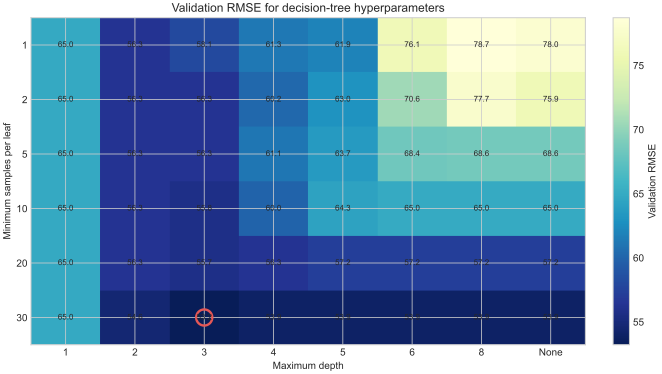

In [3]:
def regression_metrics(response, prediction):
    return {
        "MAE": mean_absolute_error(response, prediction),
        "RMSE": np.sqrt(mean_squared_error(response, prediction)),
        "R2": r2_score(response, prediction),
    }

depth_values = [1, 2, 3, 4, 5, 6, 8, None]
leaf_values = [1, 2, 5, 10, 20, 30]
candidate_models = {}
validation_rows = []

for max_depth in depth_values:
    for min_samples_leaf in leaf_values:
        model = DecisionTreeRegressor(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=RANDOM_STATE,
        )
        model.fit(X_train, y_train)
        validation_prediction = model.predict(X_validation)
        key = (max_depth, min_samples_leaf)
        candidate_models[key] = model
        validation_rows.append(
            {
                "max_depth": max_depth,
                "depth label": "None" if max_depth is None else str(max_depth),
                "min_samples_leaf": min_samples_leaf,
                "actual depth": model.get_depth(),
                "leaves": model.get_n_leaves(),
                **regression_metrics(y_validation, validation_prediction),
            }
        )

validation_results = pd.DataFrame(validation_rows)
best_row = validation_results.loc[validation_results["RMSE"].idxmin()]
best_max_depth = best_row["max_depth"]
if pd.isna(best_max_depth):
    best_max_depth = None
else:
    best_max_depth = int(best_max_depth)
best_min_samples_leaf = int(best_row["min_samples_leaf"])
selected_model = candidate_models[(best_max_depth, best_min_samples_leaf)]

top_validation_results = (
    validation_results[
        ["depth label", "min_samples_leaf", "actual depth", "leaves", "MAE", "RMSE", "R2"]
    ]
    .sort_values("RMSE")
    .head(10)
    .rename(columns={"depth label": "max_depth"})
)
display(top_validation_results.round(3))
print(
    "Selected parameters: "
    f"max_depth={best_max_depth}, min_samples_leaf={best_min_samples_leaf}"
)
print(f"Validation RMSE: {best_row['RMSE']:.3f}")

validation_heatmap = validation_results.pivot(
    index="min_samples_leaf",
    columns="depth label",
    values="RMSE",
).reindex(
    index=leaf_values,
    columns=[str(value) for value in depth_values[:-1]] + ["None"],
)
fig, ax = plt.subplots(figsize=(9.2, 5.2), constrained_layout=True)
image = ax.imshow(validation_heatmap.to_numpy(), aspect="auto", cmap="YlGnBu_r")
for row in range(validation_heatmap.shape[0]):
    for column in range(validation_heatmap.shape[1]):
        value = validation_heatmap.iloc[row, column]
        ax.text(column, row, f"{value:.1f}", ha="center", va="center", fontsize=8)
best_depth_label = "None" if best_max_depth is None else str(best_max_depth)
best_column = list(validation_heatmap.columns).index(best_depth_label)
best_grid_row = list(validation_heatmap.index).index(best_min_samples_leaf)
ax.scatter(
    best_column,
    best_grid_row,
    s=260,
    facecolors="none",
    edgecolors="#E45756",
    linewidths=2.4,
)
ax.set(
    title="Validation RMSE for decision-tree hyperparameters",
    xlabel="Maximum depth",
    ylabel="Minimum samples per leaf",
    xticks=np.arange(validation_heatmap.shape[1]),
    xticklabels=validation_heatmap.columns,
    yticks=np.arange(validation_heatmap.shape[0]),
    yticklabels=validation_heatmap.index,
)
fig.colorbar(image, ax=ax, label="Validation RMSE")
plt.show()


## 3. 在测试集上评价选定模型

选定参数后，在测试集上进行测试


,test result
selected max_depth,3.000
selected min_samples_leaf,30.000
actual depth,3.000
leaves,6.000
MAE,49.292
RMSE,62.859
R2,0.317


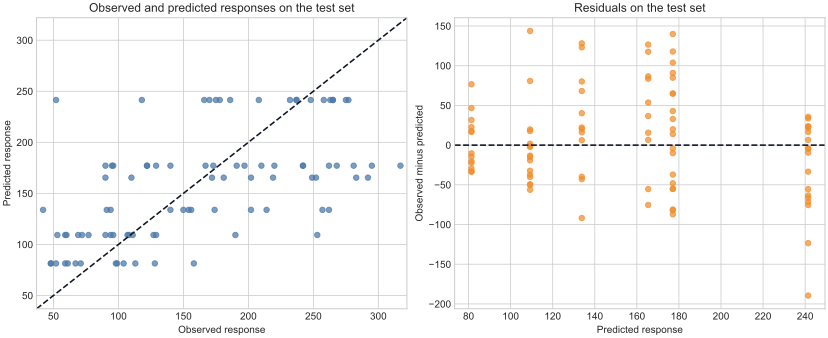

In [4]:
test_prediction = selected_model.predict(X_test)
test_residual = y_test.to_numpy() - test_prediction
test_results = pd.Series(
    {
        "selected max_depth": best_max_depth,
        "selected min_samples_leaf": best_min_samples_leaf,
        "actual depth": selected_model.get_depth(),
        "leaves": selected_model.get_n_leaves(),
        **regression_metrics(y_test, test_prediction),
    },
    name="test result",
).to_frame()
display(test_results.round(3))

plot_min = min(y_test.min(), test_prediction.min()) - 5
plot_max = max(y_test.max(), test_prediction.max()) + 5
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.7), constrained_layout=True)
axes[0].scatter(y_test, test_prediction, s=30, alpha=0.72, color="#4C78A8")
axes[0].plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
    linewidth=1.6,
    color="#111827",
)
axes[0].set(
    title="Observed and predicted responses on the test set",
    xlabel="Observed response",
    ylabel="Predicted response",
    xlim=(plot_min, plot_max),
    ylim=(plot_min, plot_max),
)
axes[1].scatter(test_prediction, test_residual, s=30, alpha=0.72, color="#F28E2B")
axes[1].axhline(0, linestyle="--", linewidth=1.6, color="#111827")
axes[1].set(
    title="Residuals on the test set",
    xlabel="Predicted response",
    ylabel="Observed minus predicted",
)
plt.show()
